In [1]:
#自动重载外部文件的更新
import numpy as np
%load_ext autoreload
%autoreload 2

# 添加项目路径至path
import os
import sys
currentPath = os.path.join(os.getcwd(),"machinelearningIntro","机器学习实践/聚类/kmeans")
sys.path.append(currentPath)

In [2]:
import pandas as pd

In [3]:
datadir = r"D:\PythonEx\machinelearningIntro\data\bank_customers.xlsx"

data = pd.read_excel(datadir)

In [4]:
data = data.iloc[:,1:]
data = data.dropna()

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 150 entries, 40 to 189
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            150 non-null    int64  
 1   income         150 non-null    int64  
 2   score          150 non-null    int64  
 3   gender_female  150 non-null    int64  
 4   gender_male    150 non-null    int64  
 5   cluster        150 non-null    float64
dtypes: float64(1), int64(5)
memory usage: 8.2 KB


In [6]:
data.head()

,age,income,score,gender_female,gender_male,cluster
40,65,38,35,1,0,1.0
41,24,38,92,0,1,1.0
42,48,39,36,0,1,1.0
43,31,39,61,1,0,1.0
44,49,39,28,1,0,1.0


In [7]:
data = data.reset_index()

In [8]:
data.describe()

,index,age,income,score,gender_female,gender_male,cluster
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,114.500000,40.173333,66.240000,50.533333,0.546667,0.453333,0.993333
std,43.445368,14.204993,16.824271,23.371142,0.499485,0.499485,0.670537
min,40.000000,18.000000,38.000000,1.000000,0.000000,0.000000,0.000000
25%,77.250000,29.000000,54.000000,40.250000,0.000000,0.000000,1.000000
50%,114.500000,38.000000,65.000000,50.000000,1.000000,0.000000,1.000000
75%,151.750000,49.750000,78.000000,60.000000,1.000000,1.000000,1.000000
max,189.000000,70.000000,103.000000,97.000000,1.000000,1.000000,2.000000


In [9]:
data["cluster"].value_counts()

1.0    83
0.0    34
2.0    33
Name: cluster, dtype: int64

In [10]:
import numpy as np

random_train_index = np.random.choice(list(data.index), 140,False)
train_data = data.iloc[random_train_index]

test_index = [i for i in list(data.index) if i not in random_train_index ]
test_data = data.iloc[test_index]

In [11]:
train_data.shape

(140, 7)

In [12]:
test_data.shape


(10, 7)

In [13]:
test_data.shape


(10, 7)

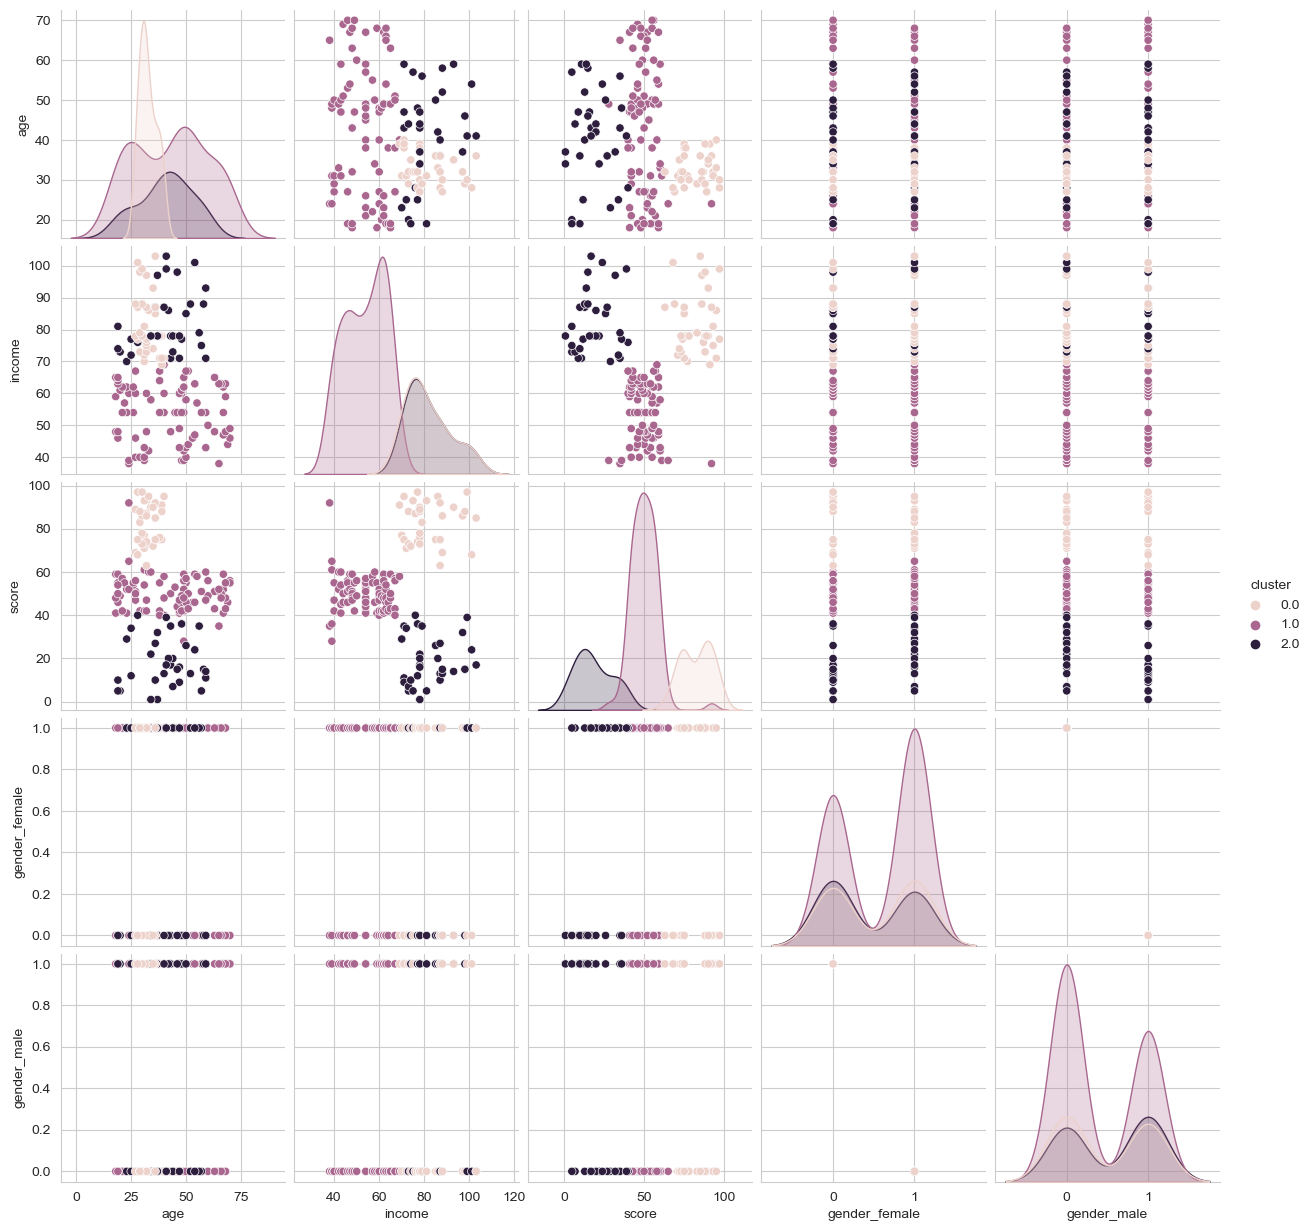

In [14]:
import seaborn as sns
sns.pairplot(data.iloc[:,1:],hue="cluster")


In [15]:
# 把没有标记cluster的作为训练集,剩余的作为预测集
data = pd.read_excel(datadir)

In [16]:
train_data = data[data.cluster.notna()]
train_data.shape

(150, 7)

In [17]:
test_data = data[data.cluster.isna()]
test_data.shape


(50, 7)

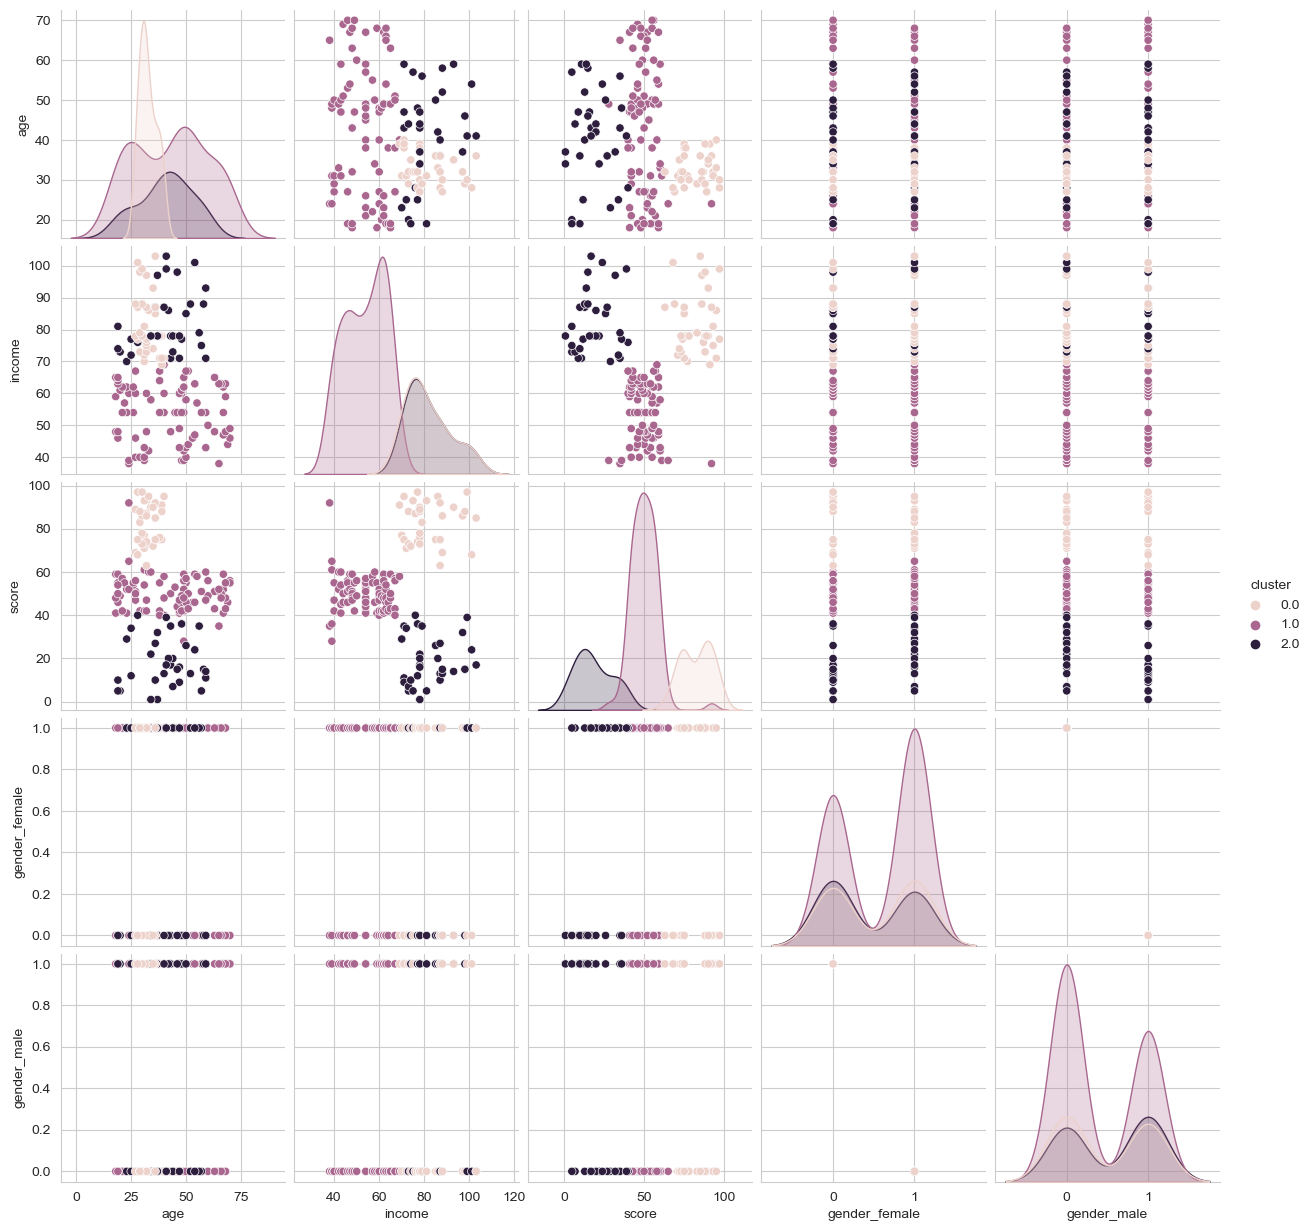

In [18]:
sns.pairplot(data.iloc[:,1:],hue="cluster")

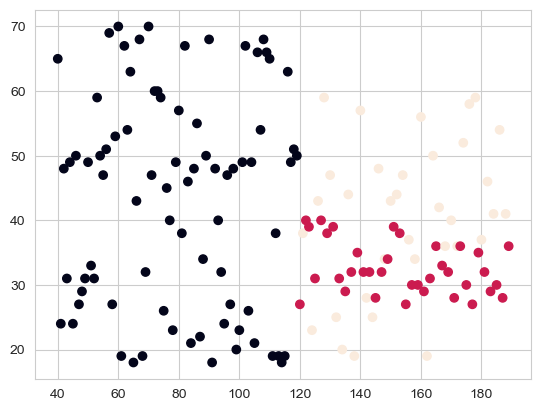

In [19]:
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

y_pred = KMeans(n_clusters=3, random_state=9).fit_predict(train_data)
y_pred
plt.scatter(train_data.iloc[:, 0], train_data.iloc[:, 1], c=y_pred)
plt.show()


In [20]:
model = KMeans(n_clusters=3, random_state=9)
model.fit_predict(train_data)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1])

D:\software\anaconda3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 23646 (\N{CJK UNIFIED IDEOGRAPH-5C5E}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\software\anaconda3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\software\anaconda3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21644 (\N{CJK UNIFIED IDEOGRAPH-548C}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


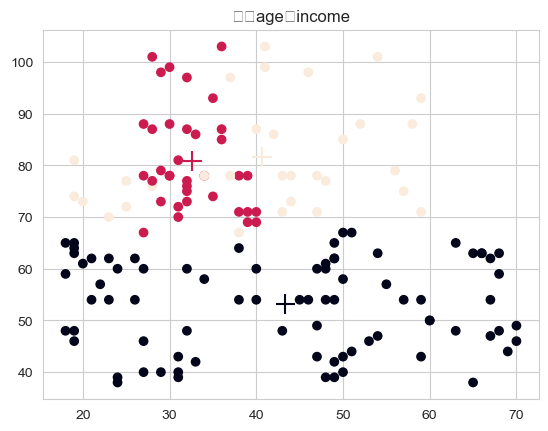

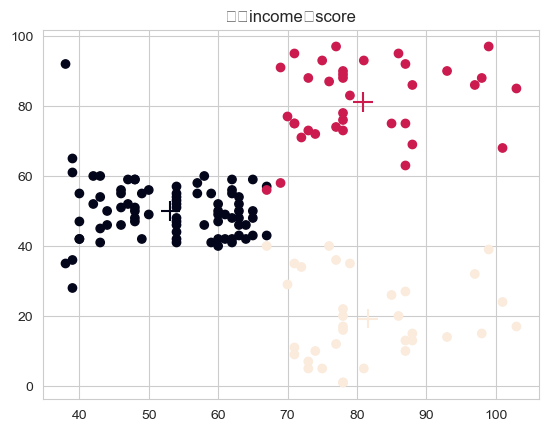

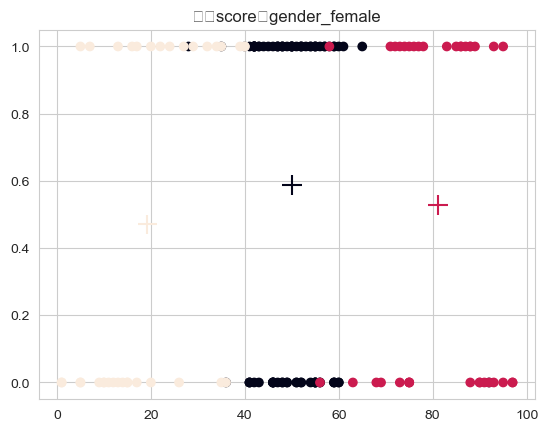

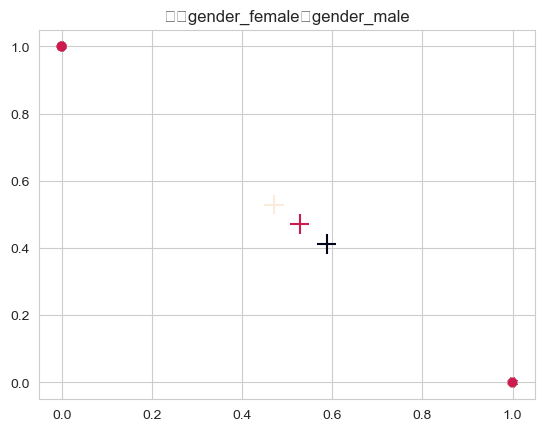

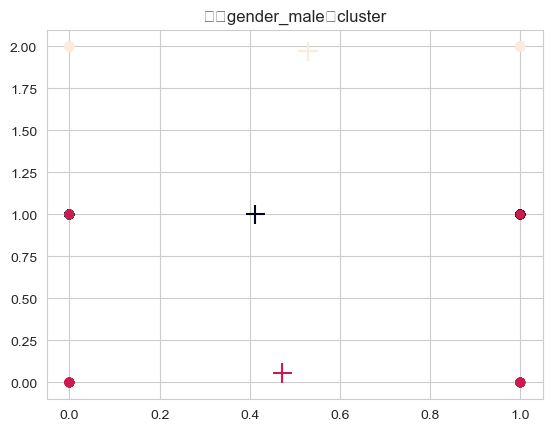

In [21]:
for i in range(1,6):
    plt.scatter(train_data.iloc[:, i], train_data.iloc[:, i+1], c=y_pred)
    plt.scatter(model.cluster_centers_[:,i], model.cluster_centers_[:,i+1],marker="+",c = list(range(3)),s = 200)
    plt.title(f"属性{train_data.columns[i]}和{train_data.columns[i+1]}")
    # plt.xlabel(train_data.columns[i])
    # plt.ylabel(train_data.columns[i+1])
    plt.show()

In [22]:
import seaborn as sns

rc = {'font.sans-serif': 'SimHei',
      'axes.unicode_minus': False}
sns.set(context='notebook', style='ticks', rc=rc)

In [23]:
model.inertia_

125583.20138888889

Text(0.5, 1.0, '肘子图')

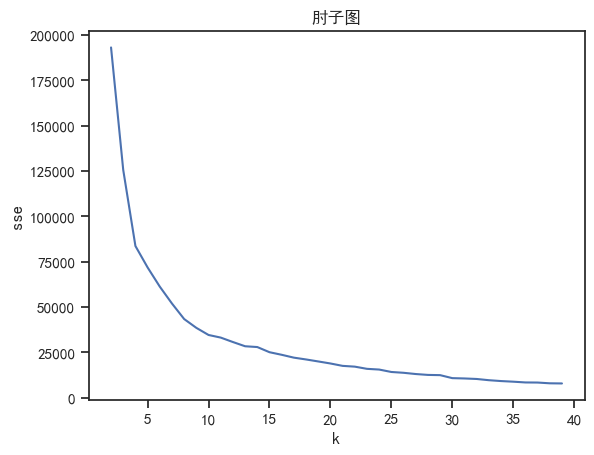

In [24]:
df = pd.DataFrame(columns=['k', 'sse'])

df.columns = ['k', 'sse']

for k in range(2,40):
    model = KMeans(n_clusters=k, random_state=9)
    model.fit_predict(train_data)
    sse = model.inertia_
    df.loc[len(df)] = [k, sse]


ax = sns.lineplot(x=df.k, y=df.sse)
ax.set_title("肘子图")

In [25]:
from mykmeans import my_k_means

Text(0.5, 1.0, '肘子图')

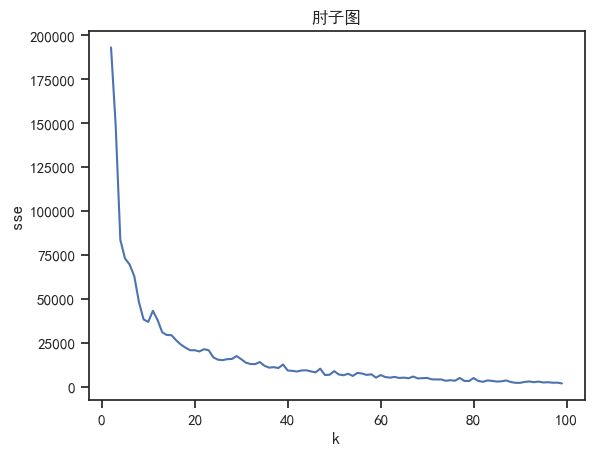

In [28]:

x = np.array(train_data)

df = pd.DataFrame(columns=['k', 'sse'])

df.columns = ['k', 'sse']
for k in range(2, 100):
    model = my_k_means(x, k)
    df.loc[len(df)] = [k, model.sse]

ax = sns.lineplot(x=df.k, y=df.sse)
ax.set_title("肘子图")
